# Model Comparison and Joint Analysis

## Objective
This notebook compares the two monomodel branches and the synthetic fusion results in one place. The goal is to answer the dissertation question directly: what is genuinely learned, what is robust, and what appears to be inflated by the pairing strategy.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from src.fusion import comparison_table
from src.metrics import save_metric_barplot

wisconsin_metrics = pd.read_csv(REPORTS / 'wisconsin_published_metrics.csv')
breakhis_metrics = pd.read_csv(METRICS / 'breakhis_patient_level_metrics.csv')
fusion_summary = pd.read_csv(METRICS / 'synthetic_fusion_summary.csv')


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


In [2]:
rows = [
    {
        'family': 'monomodel',
        'model': 'Wisconsin published branch',
        'accuracy': float(wisconsin_metrics[wisconsin_metrics['metric'] == 'accuracy']['value'].iloc[0]),
        'roc_auc': float(wisconsin_metrics[wisconsin_metrics['metric'] == 'roc_auc']['value'].iloc[0]),
        'calibration_or_stability': 'MC Dropout reported in source notebook',
        'claim_type': 'published frozen branch',
    },
    {
        'family': 'monomodel',
        'model': 'BreaKHis corrected patient-level model',
        'accuracy': float(breakhis_metrics['accuracy'].iloc[0]),
        'roc_auc': float(breakhis_metrics['roc_auc'].iloc[0]),
        'calibration_or_stability': f"ECE={breakhis_metrics['ece'].iloc[0]:.3f}",
        'claim_type': 'new defendable image result',
    },
]
for pairing_type, experiment in [('same_label', 'early_fusion'), ('random', 'early_fusion'), ('random', 'late_fusion')]:
    subset = fusion_summary[(fusion_summary['pairing_type'] == pairing_type) & (fusion_summary['experiment'] == experiment)]
    rows.append(
        {
            'family': 'synthetic_fusion',
            'model': f'{pairing_type} | {experiment}',
            'accuracy': float(subset[subset['metric'] == 'accuracy']['mean'].iloc[0]),
            'roc_auc': float(subset[subset['metric'] == 'roc_auc']['mean'].iloc[0]),
            'calibration_or_stability': f"std_acc={subset[subset['metric'] == 'accuracy']['std'].iloc[0]:.3f}",
            'claim_type': 'exploratory only',
        }
    )
comparison_df = comparison_table(rows)
comparison_df.to_csv(METRICS / 'joint_model_comparison.csv', index=False)
comparison_df


,family,model,accuracy,roc_auc,calibration_or_stability,claim_type
0,monomodel,BreaKHis corrected patient-level model,0.769231,0.916667,ECE=0.231,new defendable image result
1,monomodel,Wisconsin published branch,0.960000,0.997000,MC Dropout reported in source notebook,published frozen branch
2,synthetic_fusion,random | early_fusion,0.971930,0.991799,std_acc=0.020,exploratory only
3,synthetic_fusion,random | late_fusion,0.977193,0.987500,std_acc=0.008,exploratory only
4,synthetic_fusion,same_label | early_fusion,0.998246,1.000000,std_acc=0.004,exploratory only


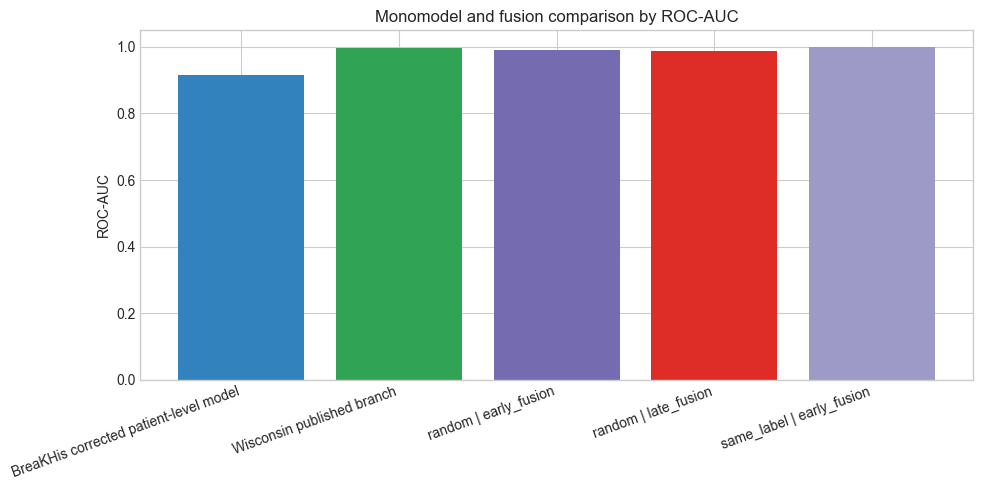

In [3]:
plot_df = comparison_df[['model', 'accuracy', 'family']]
save_metric_barplot(
    plot_df,
    x='model',
    y='accuracy',
    hue='family',
    output_path=FIGURES / 'joint_model_accuracy_comparison.png',
    title='Monomodel and fusion comparison by accuracy',
    ylabel='Accuracy',
)

plot_df_auc = comparison_df[['model', 'roc_auc', 'family']].rename(columns={'roc_auc': 'value'})
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df_auc['model'], plot_df_auc['value'], color=['#3182bd', '#31a354', '#756bb1', '#de2d26', '#9e9ac8'])
ax.set_title('Monomodel and fusion comparison by ROC-AUC')
ax.set_ylabel('ROC-AUC')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(FIGURES / 'joint_model_roc_auc_comparison.png', dpi=300)
plt.show()


In [4]:
analysis_notes = pd.DataFrame(
    [
        {'question': 'Which monomodel is strongest on its own?', 'answer': 'The frozen Wisconsin branch reports the highest published metrics, but it remains a reused external component rather than new work.'},
        {'question': 'What is the main new defendable result?', 'answer': 'The corrected patient-level BreaKHis model provides the strongest new unimodal result because leakage is removed.'},
        {'question': 'Do synthetic fusion gains look genuine?', 'answer': 'Only cautiously. Same-label pairing inflates alignment, while random-pairing controls are much weaker.'},
        {'question': 'What should be claimed in the dissertation?', 'answer': 'Use unimodal findings as defendable claims and treat synthetic fusion as methodological exploration.'},
    ]
)
analysis_notes


,question,answer
0,Which monomodel is strongest on its own?,The frozen Wisconsin branch reports the highes...
1,What is the main new defendable result?,The corrected patient-level BreaKHis model pro...
2,Do synthetic fusion gains look genuine?,Only cautiously. Same-label pairing inflates a...
3,What should be claimed in the dissertation?,Use unimodal findings as defendable claims and...


## Interpretation

The side-by-side comparison clarifies the project's contribution. The Wisconsin branch shows what a strong frozen tabular component looks like. The corrected BreaKHis branch provides the main new defendable experimentation. The synthetic fusion study is useful, but primarily because it reveals how easily artificial pairing can inflate multimodal performance.
